In [5]:
agol = GIS()

In [89]:
m = agol.map('Wadi As-Sirhan, Saudi Arabia', zoomlevel=9)

In [93]:
m

In [90]:
l8 = agol.content.search('"Landsat Multispectral"', 'Imagery Layer')[0]
l8

<Item title:"Multispectral Landsat" type:Image Service owner:esri>

In [91]:
l8lyr = l8.layers[0]

In [92]:
m.add_layer(l8lyr)

In [25]:
from arcgis.raster.functions import *

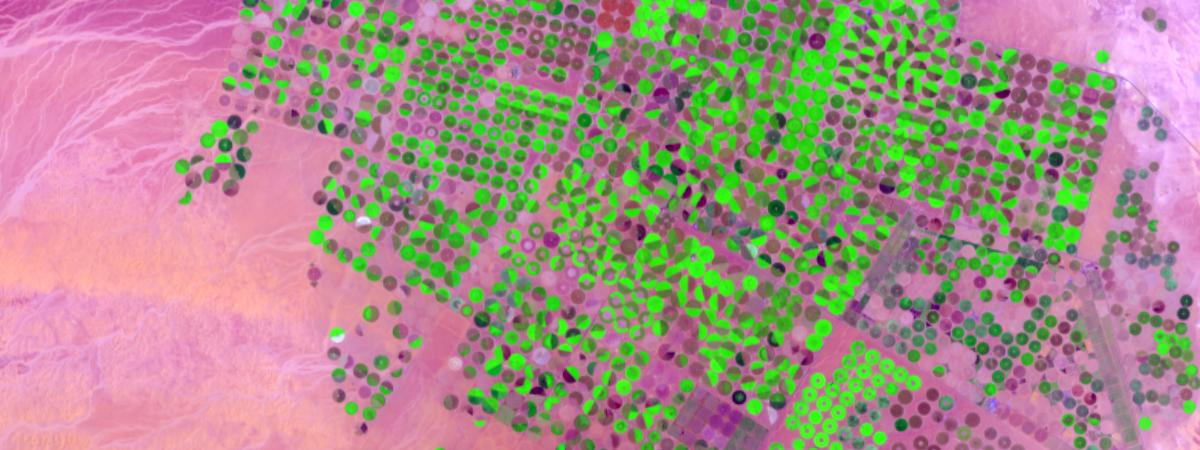

In [94]:
l8lyr.extent = {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'type': 'extent',
 'xmax': 4296559.143733407,
 'xmin': 4219969.241391764,
 'ymax': 3522726.823081019,
 'ymin': 3492152.0117669892}
l8lyr


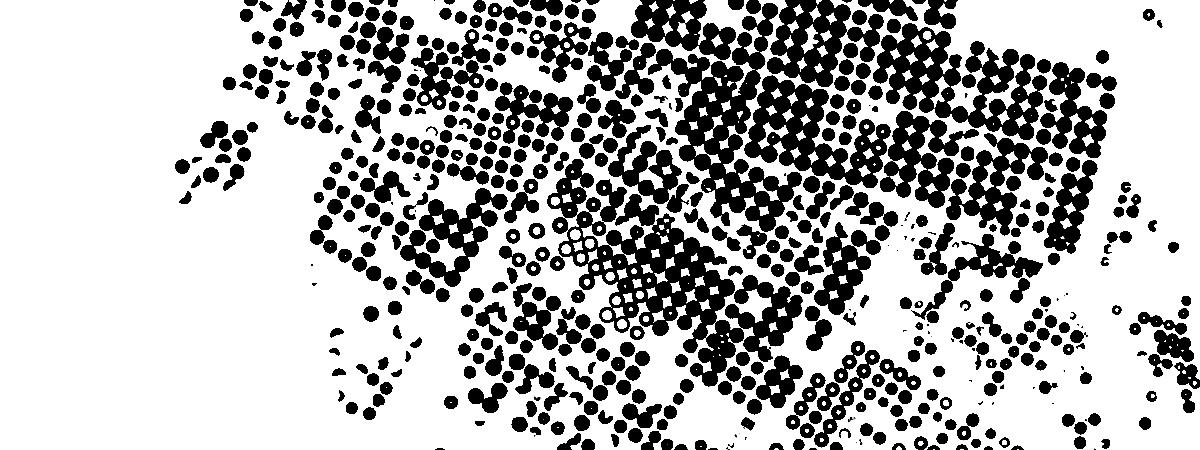

In [68]:
stretch(ndvi(l8lyr), stretch_type='PercentClip', min_percent=30, max_percent=70, dra=True)

In [69]:
img = stretch(ndvi(l8lyr), stretch_type='PercentClip', min_percent=30, max_percent=70, dra=True).export_image(bbox=m.extent, bbox_sr=102100, size=[1200, 450],
                       export_format='jpeg', save_folder='c:\\xc', save_file='saudiarabia.jpg', f='image')

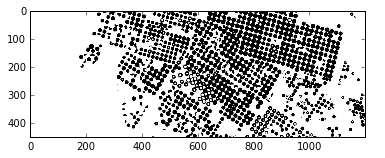

In [70]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# load the famous Lena image
img = mpimg.imread('c:\\xc\\saudiarabia.jpg')

# what does it look like?
plt.imshow(img)
plt.show()

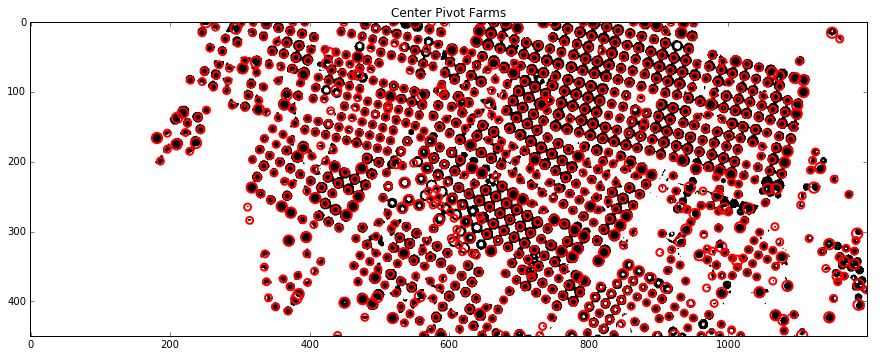

TypeError: Can't convert 'int' object to str implicitly

In [97]:
from skimage import feature, color
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

bw = img.mean(axis=2)
#plt.imshow(bw, cmap='gray')
# plt.show()

fig=plt.figure(figsize = (15,15))
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(-bw, 
                                                        min_sigma=4, 
                                                        max_sigma=8,
                                                        threshold=0.1,
                                                        overlap=0.6)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)

for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r+1, color='red', linewidth=2, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('Center Pivot Farms')

plt.show()
print('Number of center pivot farms detected: ' + len(blobs_dog))

In [62]:
from arcgis.raster.functions import *

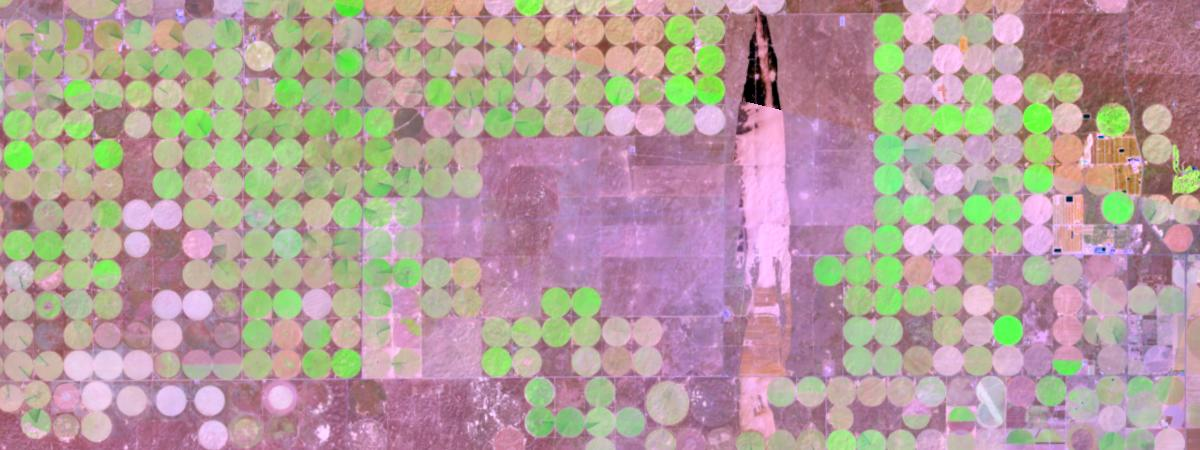

In [63]:
l8lyr

In [69]:
l8img = convolution(stretch(l8lyr,stretch_type='PercentClip', dra=True, min_percent=5, max_percent=5), 
            arcgis.raster.kernels.SMOOTHING_5X5)

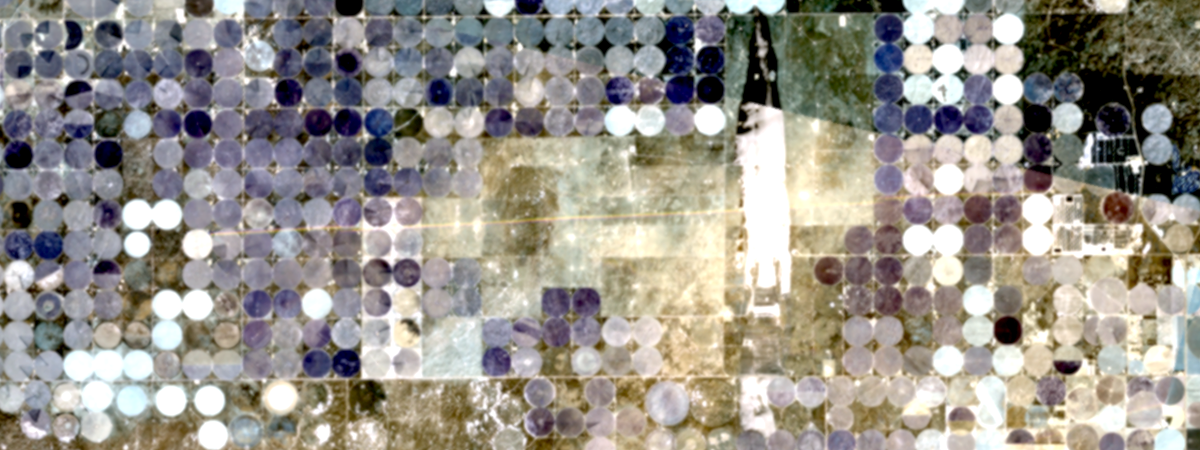

In [77]:
from IPython.display import Image

exported_image = l8img.export_image(size=[1200, 450], export_format='png', f='image',
                                    save_folder='C:\\xc', save_file='x.png')
Image(exported_image)

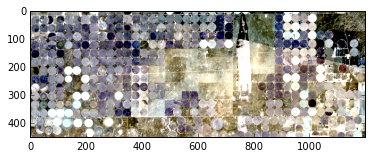

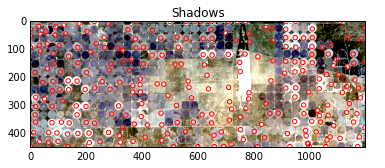

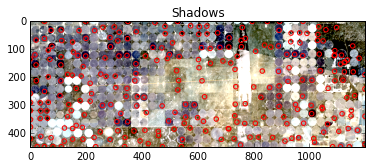

In [85]:
from skimage import feature, color
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# load the famous Lena image
img = mpimg.imread(exported_image)

# what does it look like?
plt.imshow(img)
plt.show()
bw = img.mean(axis=2)
plt.imshow(bw, cmap='gray')
# plt.show()

fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(bw, 
                                                        min_sigma=8, 
                                                        max_sigma=12,
                                                        threshold=0.3,
                                                        overlap=0.9)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('Shadows')

plt.show()

fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(-bw, 
                                                        min_sigma=8, 
                                                        max_sigma=12,
                                                        threshold=0.3,
                                                        overlap=0.9)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('Shadows')

plt.show()

In [44]:
m.add_layer(l8)

In [41]:
l8

<Item title:"Landsat Layers" type:Web Map owner:esri>

<Item title:"Uruguay_subset_VNIR" type:Image Service owner:arcgis_python_api>
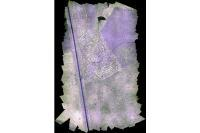

In [2]:
trees = gis.content.search('Uruguay', 'Imagery Layer')[0]
trees

In [1]:
gis = GIS('https://dev003246.esri.com/portal/', 'admin', 'esri.agp')

In [3]:
uruguay_trees = trees.layers[0]

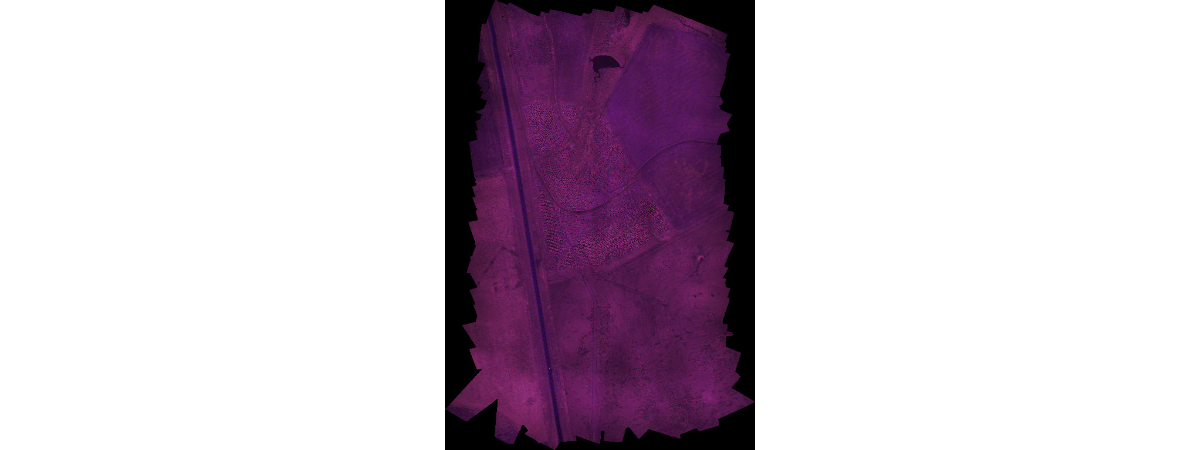

In [4]:
uruguay_trees

In [5]:
m = gis.map('Uruguay')
m

In [7]:
m.extent = dict(uruguay_trees.properties.extent)

In [6]:
url = 'http://dev003248.esri.com/rax/rest/services/Uruguay_subset_VNIR/ImageServer'
from arcgis.raster import ImageryLayer

lyr = ImageryLayer(url, gis)

In [7]:
m.add_layer(lyr)

NameError: name 'm' is not defined

In [11]:
uruguay_trees.properties.extent

{
  "ymin": -33.36838107386213,
  "spatialReference": {
    "latestWkid": 4326,
    "wkid": 4326
  },
  "xmax": -57.0337648633403,
  "ymax": -33.357011796250134,
  "xmin": -57.0415816103243
}

In [5]:
lyr

NameError: name 'lyr' is not defined

In [6]:
lyr.extent = ext = {"type":"extent","xmin":-6349506.514113078,"ymin":-3943549.833446034,"xmax":-6349446.648393678,"ymax":-3943519.975231869,"spatialReference":{"wkid":102100,"latestWkid":3857}}

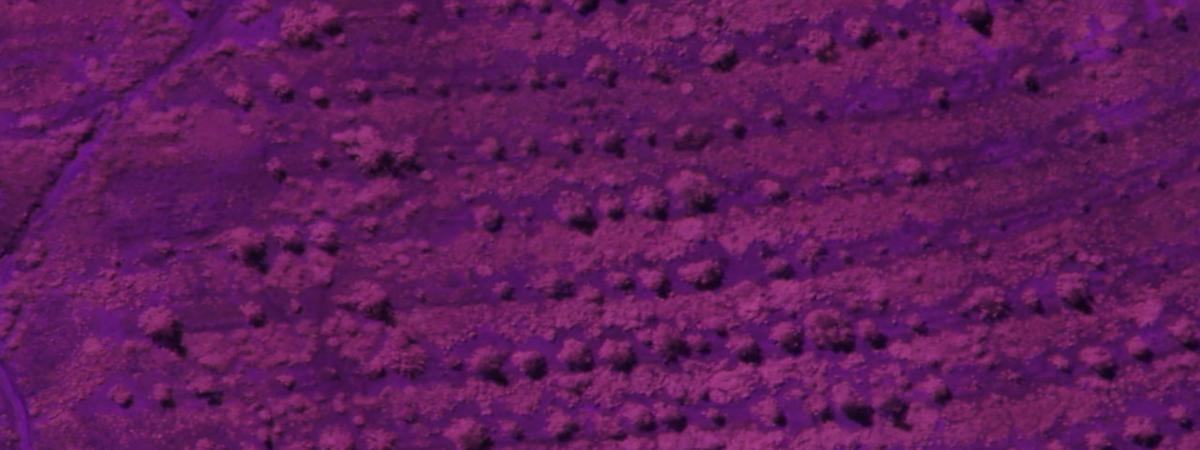

In [7]:
lyr

In [15]:
img = strlyr2.export_image(bbox=ext, bbox_sr=102100, size=[1200, 450],
                       export_format='jpeg', save_folder='c:\\xc', save_file='img.jpg', f='image')

In [16]:
img

'c:\\xc\\img.jpg'

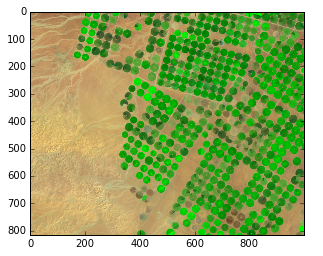

In [27]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# load the famous Lena image
img = mpimg.imread('c:\\xc\\centerpivot.png')

# what does it look like?
plt.imshow(img)
plt.show()

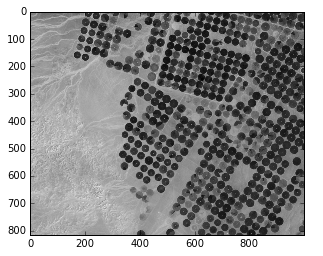

In [3]:
# make it B&W
bw = img.mean(axis=2)
plt.imshow(bw, cmap='gray')
plt.show()

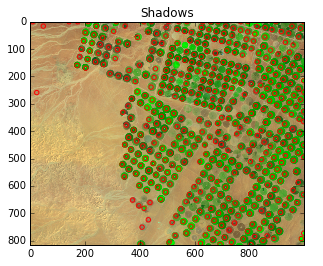

In [28]:
from skimage import feature, color
fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(-bw, 
                                                        min_sigma=8, 
                                                        max_sigma=12,
                                                        threshold=0.1,
                                                        overlap=0.9)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('Shadows')

plt.show()

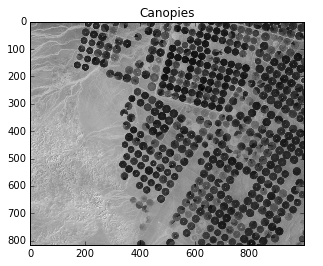

In [13]:
from skimage import feature
fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_log(bw, min_sigma=16, max_sigma=16)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
	ax.add_patch(c)

plt.imshow(bw, cmap='gray')
plt.title('Canopies')

plt.show()

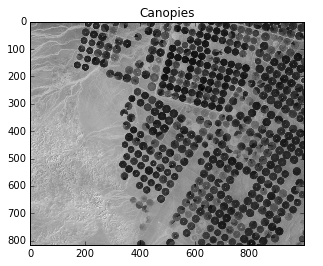

In [14]:
from skimage import feature
fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_doh(bw, min_sigma=16, max_sigma=16)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=1, fill=False)
	ax.add_patch(c)

plt.imshow(bw, cmap='gray')
plt.title('Canopies')

plt.show()

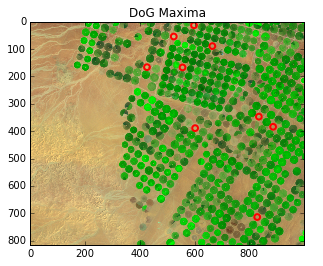

In [15]:
from skimage import data, feature, color, filters, img_as_float
from matplotlib import pyplot as plt

#original_image = img #img_as_float(data.chelsea())
#img = color.rgb2gray(original_image)

fig=plt.figure(1)
#plt.axis([0,400,0,400])
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(bw, min_sigma=1, max_sigma=16,threshold=0.5,overlap=0.75)]
# skimage has a bug in my version where only maxima were returned by the above
#blobs_dog += [(x[0],x[1],x[2]) for x in feature.blob_dog(-img, min_sigma=4, max_sigma=32,threshold=0.5,overlap=1.0)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('DoG Maxima')

plt.show()

In [14]:
from arcgis.raster.functions import *

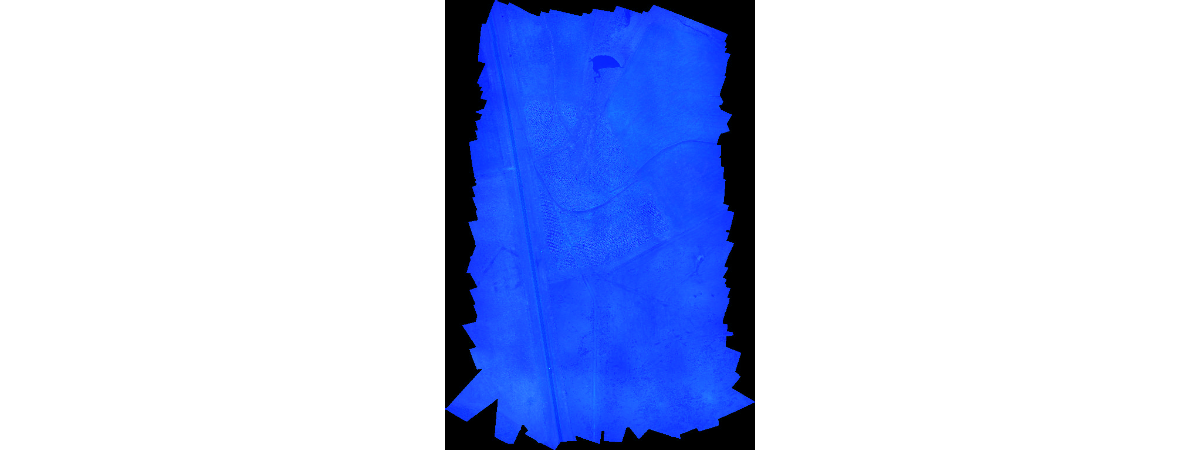

In [18]:
extract_band(lyr, band_ids=[1,2,3])

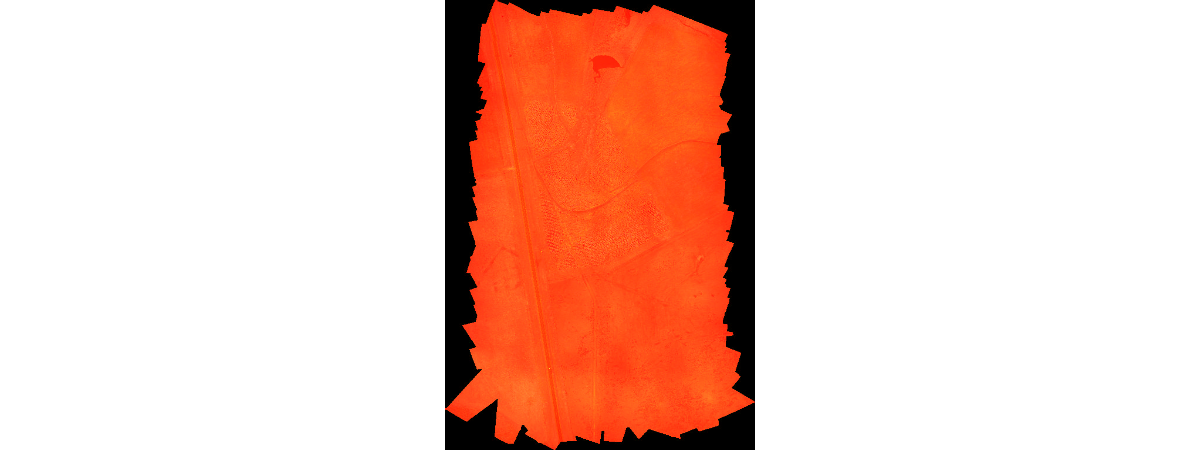

In [19]:
extract_band(lyr, band_ids=[3,2,1])

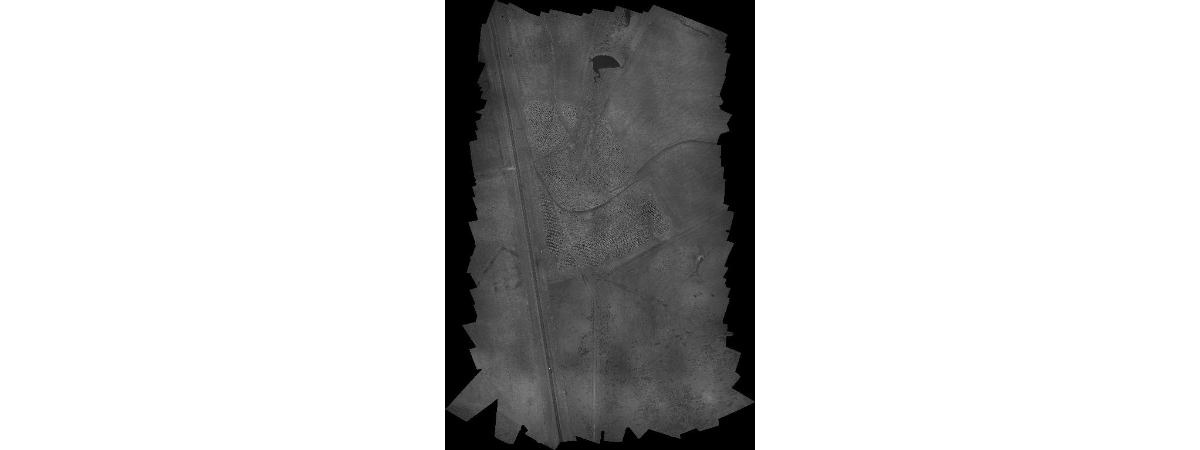

In [29]:
extract_band(lyr, band_ids=[2,2, 2])

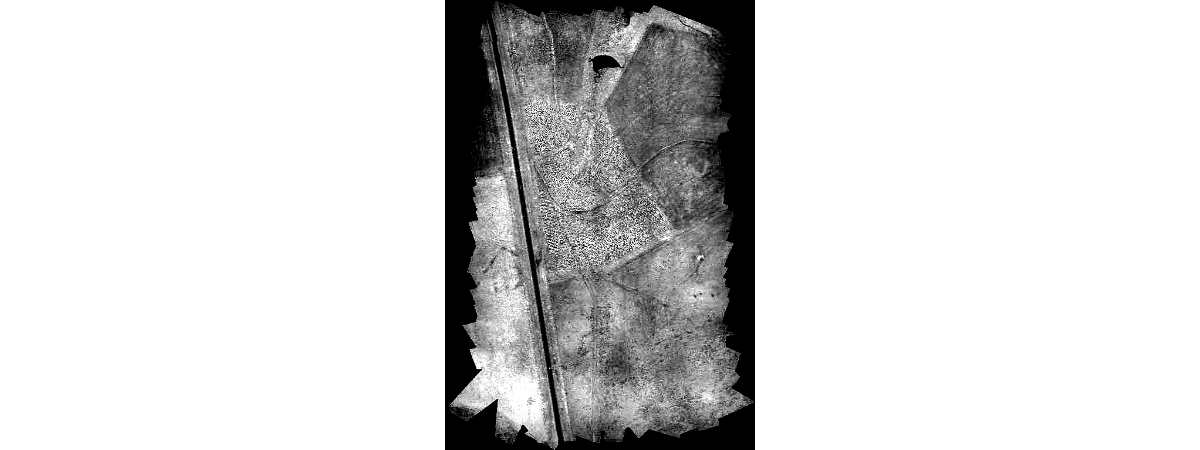

In [16]:
strlyr2 = stretch(extract_band(lyr, band_ids=[1,1, 1]), min_percent=5, max_percent=5, stretch_type='PercentClip', dra=True)
strlyr2

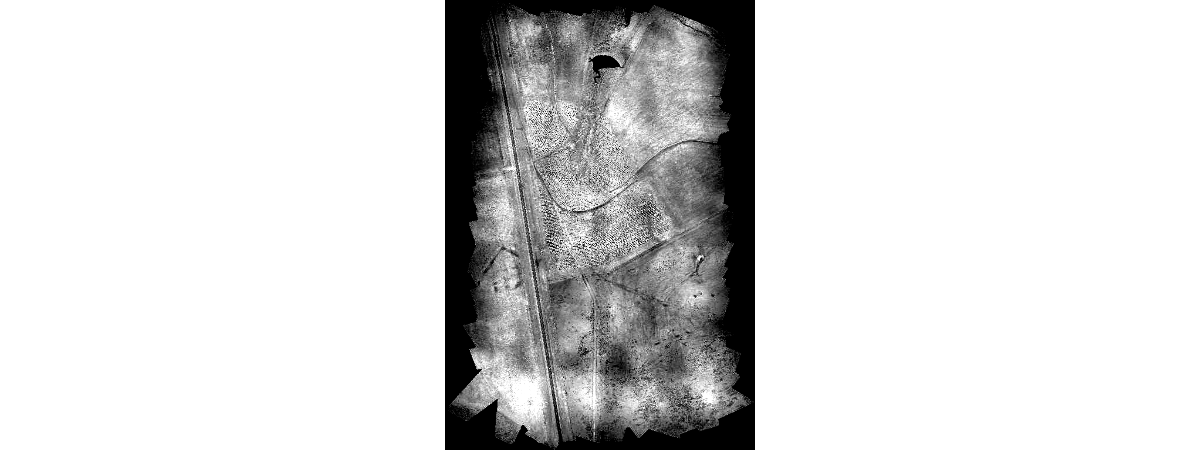

In [34]:
strlyr1 = stretch(extract_band(lyr, band_ids=[2, 2, 2]), min_percent=5, max_percent=5, stretch_type='PercentClip', dra=True)
strlyr1

In [35]:
m2 = gis.map('Uruguay')
m2.extent = dict(lyr.properties.extent)
m2.add_layer(strlyr1)
m2

In [17]:
m.add_layer(strlyr2)

In [39]:
m2.extent

{'spatialReference': {'latestWkid': 4326, 'wkid': 4326},
 'xmax': -57.0337648633403,
 'xmin': -57.0415816103243,
 'ymax': -33.357011796250134,
 'ymin': -33.36838107386213}

In [40]:
dict(lyr.properties.extent)

{'spatialReference': {'latestWkid': 4326, 'wkid': 4326},
 'xmax': -57.0337648633403,
 'xmin': -57.0415816103243,
 'ymax': -33.357011796250134,
 'ymin': -33.36838107386213}

In [7]:
ext = {"type":"extent","xmin":-6349506.514113078,"ymin":-3943549.833446034,"xmax":-6349446.648393678,"ymax":-3943519.975231869,"spatialReference":{"wkid":102100,"latestWkid":3857}}

In [13]:
from arcgis.raster.functions import *

strlyr2 = stretch(extract_band(lyr, band_ids=[1,1, 1]), min_percent=5, max_percent=5, stretch_type='PercentClip', dra=True)
strlyr2.extent = ext

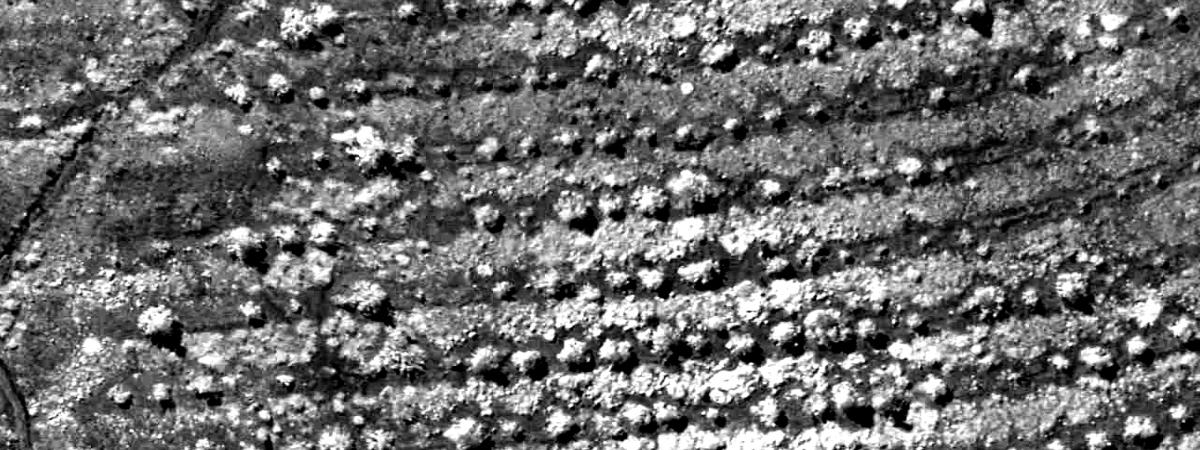

In [14]:
strlyr2

In [10]:
'spatialReference' in ext

True

###1###
###2###


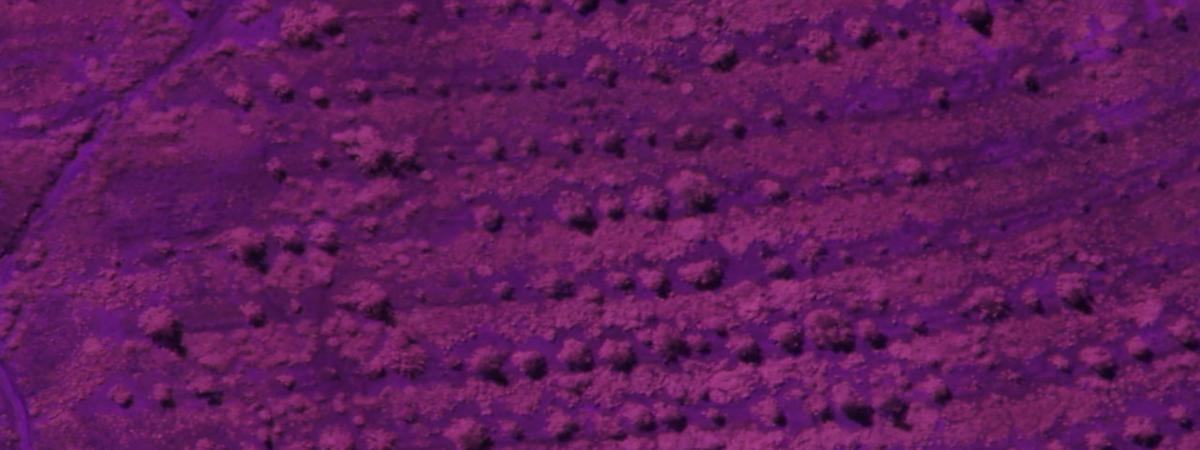

In [11]:
from IPython.display import Image

Image(lyr.export_image(bbox=ext, size=[1200, 450],export_format='jpeg', f='image'))

In [20]:
img = lyr.export_image(bbox=ext, bbox_sr=102100, size=[1200, 450],export_format='jpeg', save_folder='c:\\xc', save_file='img.jpeg', f='image')

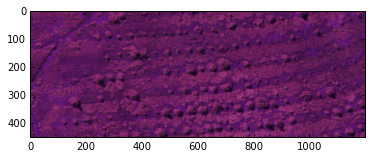

In [21]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import feature

img = mpimg.imread('c:\\xc\\img.jpeg')

plt.imshow(img)
plt.show()

In [20]:
strlyr2.extent = ext

In [24]:
img = strlyr2.export_image(bbox=ext, bbox_sr=102100, size=[1200, 450], export_format='jpeg', f='image')

In [25]:
from IPython.display import Image

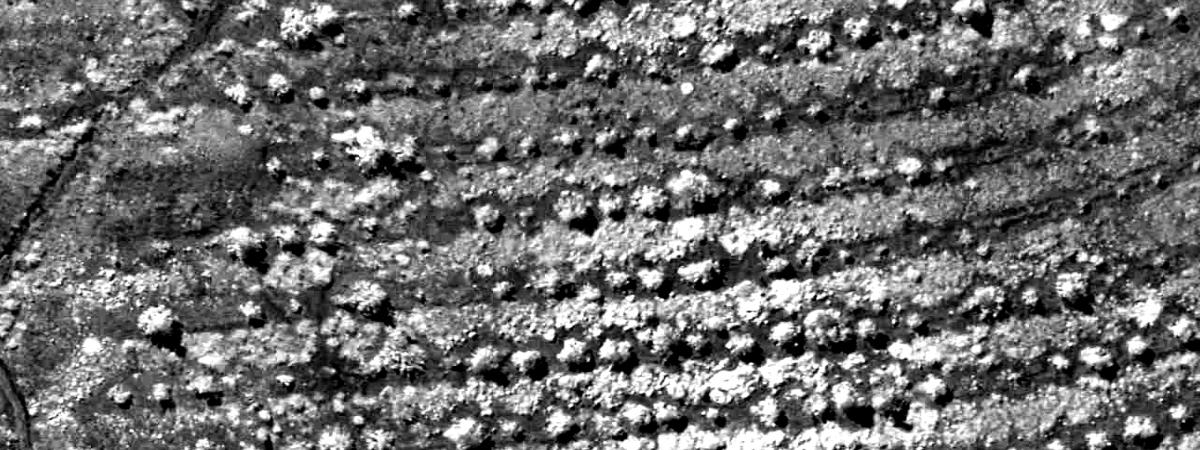

In [27]:
Image(img)

In [30]:
img = strlyr2.export_image(bbox=ext, bbox_sr=102100, size=[1200, 450], export_format='jpeg', save_folder='c:\\xc', save_file='img.jpeg', f='image')

In [31]:
img

'c:\\xc\\img.jpeg'

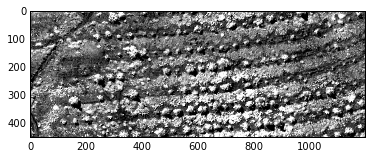

In [35]:
import numpy as np
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from skimage import feature

img = mpimg.imread('c:\\xc\\img.jpeg')

plt.imshow(img)
plt.show()

In [38]:
fig=plt.figure(1)
ax=fig.add_subplot(1,1,1)

blobs_dog = [(x[0],x[1],x[2]) for x in feature.blob_dog(bw, min_sigma=5,
                                                        max_sigma=7,
                                                        threshold=0.5,
                                                        overlap=0.1)]

#remove duplicates
blobs_dog = set(blobs_dog)

img_blobs = color.gray2rgb(img)
for blob in blobs_dog:
	y, x, r = blob
	c = plt.Circle((x, y), r, color='red', linewidth=2, fill=False)
	ax.add_patch(c)

plt.imshow(img_blobs)
plt.title('Canopies')

plt.show()

NameError: name 'bw' is not defined